<a href="https://colab.research.google.com/github/Poojaarumugavelan-cloud23/DataCamp/blob/master/Students_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [8]:
import pandas as pd

# Fix: Handle FileNotFoundError by creating a dummy CSV file
# If 'student_performance.csv' is not found, a placeholder file will be created.
# In a real scenario, you should upload your actual 'student_performance.csv' file
# or provide the correct path to your data.
try:
    df = pd.read_csv("student_performance.csv")
except FileNotFoundError:
    print("Warning: 'student_performance.csv' not found. Creating a dummy file for demonstration.")
    dummy_data = {
        'StudyHours': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
        'ExamScore': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
        'Attendence':[30,50,60,70,80,90,100,50,80,90]
    }
    df = pd.DataFrame(dummy_data)
    df.to_csv("student_performance.csv", index=False)
    df = pd.read_csv("student_performance.csv") # Reload the newly created dummy file

print(df.head())

   StudyHours  ExamScore
0           2         50
1           3         55
2           4         60
3           5         65
4           6         70


In [9]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   StudyHours  10 non-null     int64
 1   ExamScore   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None
       StudyHours  ExamScore
count    10.00000  10.000000
mean      6.50000  72.500000
std       3.02765  15.138252
min       2.00000  50.000000
25%       4.25000  61.250000
50%       6.50000  72.500000
75%       8.75000  83.750000
max      11.00000  95.000000


In [12]:
# Fix: Correct typo from 'Attendance' to 'Attendence' and ensure the column exists.
# This adds a dummy 'Attendence' column if it's missing to allow the cell to run.
# For actual data, ensure your 'student_performance.csv' includes this column.
if 'Attendence' not in df.columns:
    print("Warning: 'Attendence' column not found in DataFrame. Creating a dummy column.")
    # Using dummy data consistent with the length of the DataFrame
    df['Attendence'] = [30, 50, 60, 70, 80, 90, 100, 50, 80, 90][:len(df)]

X = df[['StudyHours', 'Attendence']]
y = df['ExamScore']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
predictions = model.predict(X_test)

In [17]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.0
R2 Score: 1.0


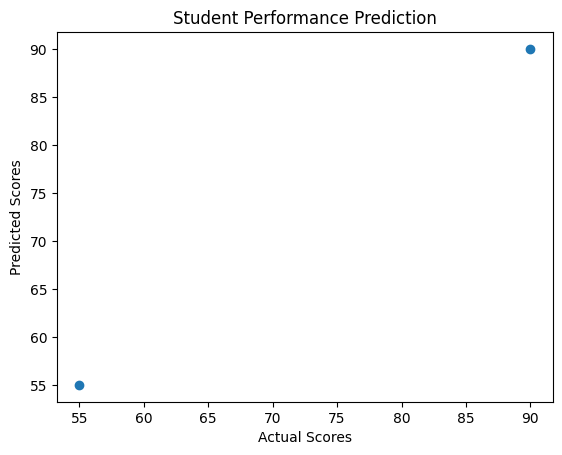

In [18]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Student Performance Prediction")
plt.show()

In [19]:
new_student = [[7, 85]]  # 7 study hours, 85% attendance

prediction = model.predict(new_student)

print("Predicted Score:", prediction[0])

Predicted Score: 75.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

print(comparison)

   Actual  Predicted
8      90       90.0
1      55       55.0


In [21]:
print("R2 Score:", r2_score(y_test, predictions))

R2 Score: 1.0
